# 02 — Mask Analysis

The Euclid Deep Field South survey footprint is encoded in a HealSparse map
(`mask_map_healsparse_EDFS_v1.fits`). This notebook:

1. Loads and inspects the HealSparse mask.
2. Computes the effective survey area.
3. Visualises the mask and shows which LRDs fall inside/outside.
4. Validates the downgraded HEALPix nside=1024 mask used by OneCovariance.

The mask is applied identically in `src.catalog.apply_sky_mask` and
`src.randoms.generate_random_catalog`, so this notebook serves as the
single place where mask quality is verified.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import healsparse

from src.config import cfg, resolve_path
from src.catalog import load_fits_catalog, filter_radec_range, apply_sky_mask

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Load the HealSparse mask

In [2]:
mask_path = str(resolve_path(cfg["fields"]["edf_s"]["mask_healsparse"]))
mask_map  = healsparse.HealSparseMap.read(mask_path)

nside_cov    = mask_map.nside_coverage
nside_sparse = mask_map.nside_sparse
pixel_area   = hp.nside2pixarea(nside_sparse, degrees=True)  # deg²

print(f"HealSparse mask: {Path(mask_path).name}")
print(f"  nside_coverage : {nside_cov}")
print(f"  nside_sparse   : {nside_sparse}")
print(f"  pixel area     : {pixel_area*3600:.4f} arcmin²")

HealSparse mask: mask_map_healsparse_EDFS_v1.fits
  nside_coverage : 32
  nside_sparse   : 131072
  pixel area     : 0.0007 arcmin²


## 2. Effective survey area

In [3]:
# Valid pixels = those where the mask is True (observed)
valid_pixels = mask_map.valid_pixels
n_valid      = len(valid_pixels)
area_deg2    = n_valid * pixel_area
area_arcmin2 = area_deg2 * 3600.0

print(f"Valid pixels   : {n_valid:,}")
print(f"Effective area : {area_deg2:.3f} deg²  ({area_arcmin2:.1f} arcmin²)")

# Compare with bounding box
survey = cfg["fields"]["edf_s"]
bbox_area = (
    (survey["ra_max"] - survey["ra_min"]) *
    np.abs(np.sin(np.radians(survey["dec_max"])) -
           np.sin(np.radians(survey["dec_min"]))) *
    (180.0 / np.pi)
)
print(f"Bounding-box area : {bbox_area:.2f} deg²")
print(f"Mask fill factor  : {area_deg2 / bbox_area * 100:.1f}%")

Valid pixels   : 111,067,168
Effective area : 22.225 deg²  (80009.6 arcmin²)
Bounding-box area : 66.21 deg²
Mask fill factor  : 33.6%


## 3. Visualise the mask (Mollweide centred on EDFS)

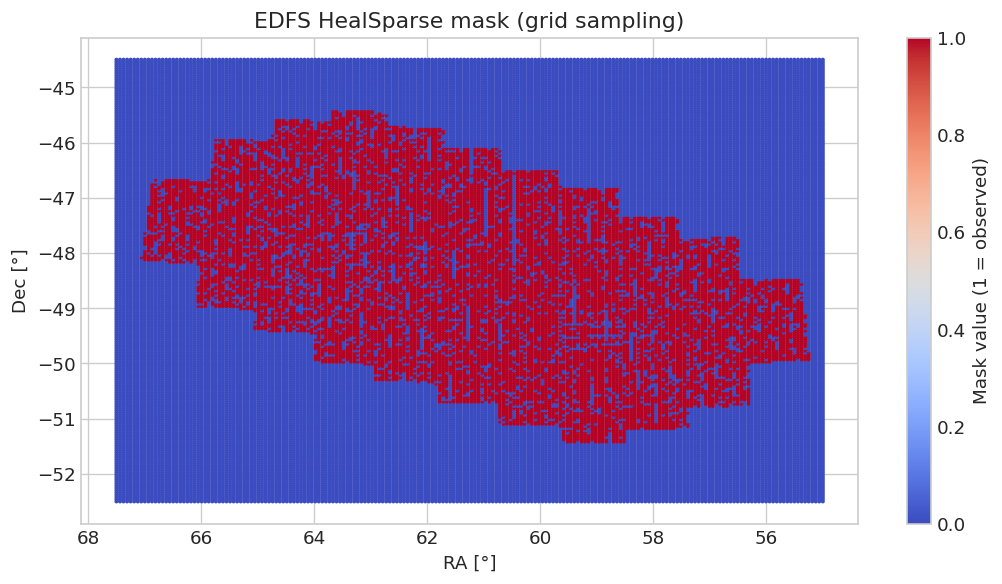

In [4]:
# Downgrade to nside=512 for plotting (full resolution is expensive to render)
nside_plot = 512
hp_map = np.zeros(hp.nside2npix(nside_plot), dtype=float)
hp_map[:] = hp.UNSEEN

ra_valid, dec_valid = healsparse.healsparse_to_healpix(
    mask_map, nside_plot, reduce="or"
).toarray() if hasattr(healsparse, "healsparse_to_healpix") else (None, None)

# Safer: use get_values_pos on a grid
ra_grid  = np.linspace(survey["ra_min"],  survey["ra_max"],  200)
dec_grid = np.linspace(survey["dec_min"], survey["dec_max"], 200)
RA, DEC  = np.meshgrid(ra_grid, dec_grid)
vals     = mask_map.get_values_pos(RA.ravel(), DEC.ravel(), lonlat=True)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    RA.ravel(), DEC.ravel(),
    c=vals.astype(float), s=2, cmap="coolwarm",
    vmin=0, vmax=1,
)
plt.colorbar(sc, ax=ax, label="Mask value (1 = observed)")
ax.set_xlabel("RA [°]")
ax.set_ylabel("Dec [°]")
ax.set_title("EDFS HealSparse mask (grid sampling)")
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## 4. Galaxies before and after masking

In [5]:
cols  = cfg["columns"]
table = load_fits_catalog(str(resolve_path(cfg["paths"]["raw_catalog"])))

# IRAC-footprint sample, sky cut only
irac_fp = np.asarray(table["IRAC-footprint"], dtype=bool)
table_fp = table[irac_fp]
table_fp = filter_radec_range(
    table_fp,
    ra_min=survey["ra_min"],  ra_max=survey["ra_max"],
    dec_min=survey["dec_min"], dec_max=survey["dec_max"],
    ra_col=cols["ra"], dec_col=cols["dec"],
)
print(f"IRAC-footprint after sky cut : {len(table_fp):,}")

# Apply mask
table_masked = apply_sky_mask(
    table_fp, mask_map, nside_sparse,
    ra_col=cols["ra"], dec_col=cols["dec"],
)
print(f"After HealSparse mask        : {len(table_masked):,}")
print(f"Rejected by mask             : {len(table_fp) - len(table_masked):,}")

Loaded catalog: /home/k3vinpaul/LRDs/data/raw/LRD_MarIRAC.fits
  Objects : 3,341
  Columns : ['ID', 'RA', 'DEC', 'z', 'z_err', 'MUV', 'MUV_err', 'beta_UV', 'beta_UV_err', 'beta_opt', 'beta_opt_err', 'IRAC-detected', 'IRAC-footprint']
Sky cut [55.0,67.5] × [-52.5,-44.5]: 1,199 / 1,509 objects kept
IRAC-footprint after sky cut : 1,199
Mask applied: 1,028 / 1,199 objects kept (85.7%)
After HealSparse mask        : 1,028
Rejected by mask             : 171


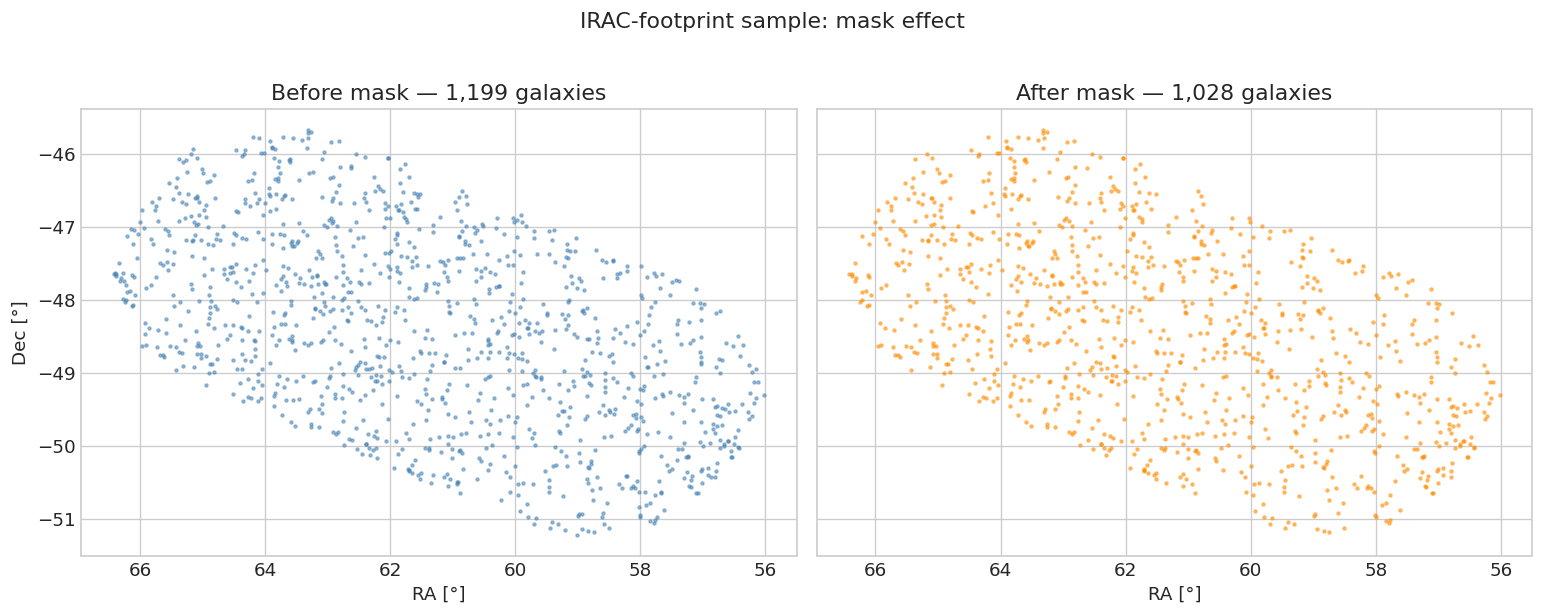

In [6]:
ra_before  = np.asarray(table_fp[cols["ra"]])
dec_before = np.asarray(table_fp[cols["dec"]])
ra_after   = np.asarray(table_masked[cols["ra"]])
dec_after  = np.asarray(table_masked[cols["dec"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, ra, dec, title, col in zip(
    axes,
    [ra_before, ra_after],
    [dec_before, dec_after],
    ["Before mask", "After mask"],
    ["steelblue", "darkorange"],
):
    ax.scatter(ra, dec, s=3, alpha=0.5, color=col)
    ax.set_xlabel("RA [°]")
    ax.set_title(f"{title} — {len(ra):,} galaxies")
    ax.invert_xaxis()
axes[0].set_ylabel("Dec [°]")
plt.suptitle("IRAC-footprint sample: mask effect", y=1.02)
plt.tight_layout()
plt.show()

## 5. HEALPix nside=1024 mask (for OneCovariance)

OneCovariance expects a standard HEALPix FITS mask rather than HealSparse.
`src.covariance.convert_healsparse_to_healpix` handles the downgrade.

In [7]:
hp_mask_path = resolve_path(cfg["paths"]["mask_healpix"])

if hp_mask_path.exists():
    hp_mask = hp.read_map(str(hp_mask_path))
    n_valid_hp = (hp_mask > 0).sum()
    area_hp    = n_valid_hp * hp.nside2pixarea(1024, degrees=True)
    print(f"HEALPix nside=1024 mask   : {hp_mask_path.name}")
    print(f"  Valid pixels            : {n_valid_hp:,}")
    print(f"  Effective area          : {area_hp:.3f} deg²")
else:
    from src.covariance import convert_healsparse_to_healpix
    print("HEALPix mask not found — generating …")
    convert_healsparse_to_healpix(
        str(resolve_path(cfg["fields"]["edf_s"]["mask_healsparse"])),
        str(hp_mask_path),
        nside_out=1024,
    )
    print(f"Saved: {hp_mask_path}")

HEALPix nside=1024 mask   : mask_healpix_nside1024.fits
  Valid pixels            : 8,856
  Effective area          : 29.034 deg²


## Summary

- The HealSparse mask correctly delineates the EDFS observed area.
- A small fraction of galaxies passing the bounding-box cut are rejected by the mask
  (edge pixels, gaps, etc.).
- The nside=1024 HEALPix mask is consistent in area with the HealSparse version.

Proceed to **03_2pacf_irac_footprint** to compute the angular correlation function.